In [96]:
import HMcode2020Emu as hmcodeemu
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
from scipy import interpolate
import cosmopower as cp
import baccoemu

## HMCode test

In [2]:
params = {
    'omega_cdm'     :  [0.315-0.05],
    'As'            :  [np.exp(3.07)*1.e-10],
    'omega_baryon'  :  [0.05],
    'ns'            :  [0.96],
    'hubble'        :  [0.67],
    'neutrino_mass' :  [0.0],
    'w0'            :  [-1.0],
    'wa'            :  [0.0],
    'log10TAGN'     :  [7.6],
    'z'             :  [0.]
}
emulator_HM = hmcodeemu.Matter_powerspectrum()

k_lin_HM, pk_lin_total_HM = emulator_HM.get_linear_pk(nonu=False, **params)
k_lin_HM, pk_lin_nonu_HM = emulator_HM.get_linear_pk(nonu=True, **params)

k_nonlin_HM, pk_nonlin_total_HM = emulator_HM.get_nonlinear_pk(nonu=False, baryonic_boost=False, **params)



Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


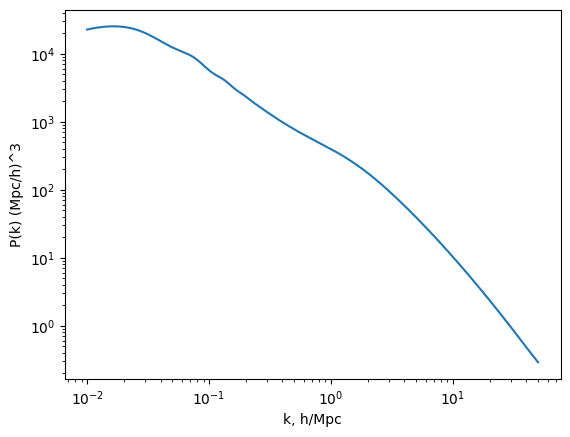

In [3]:
plt.loglog(k_nonlin_HM, pk_nonlin_total_HM[0])
plt.xlabel("k, h/Mpc")
plt.ylabel("P(k) (Mpc/h)^3")
plt.show()

## MGEmus test

In [114]:
import MGEmu as mgemu


params = {
    'Omega_m'     :  [0.315],
    'As'            :  [np.exp(3.07)*1.e-10],
    'Omega_b'  :  [0.05],
    'ns'            :  [0.96],
    'H0'        :  [67],
    'Omega_nu' :  [0.0], 
    'fR0'  :  [1e-4],
    'z'             :  [0.]}


emulator_MGEmu = mgemu.MG_boost(model='fr') #can select between fr, dgp, gamma - make sure parameters are appropriate! 

k_values_MGEmu, boost_MGEmu = emulator_MGEmu._evaluate_nonlinear(**params)

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


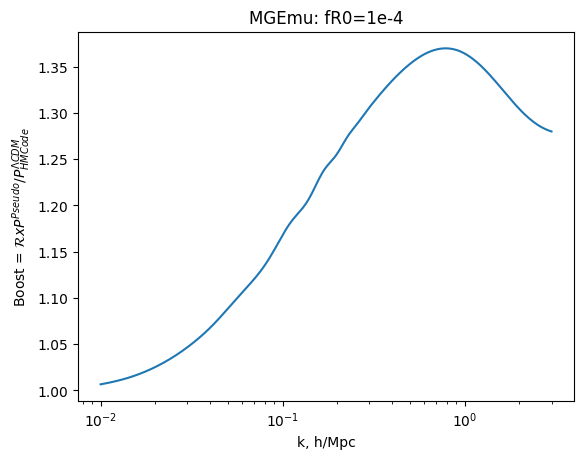

In [115]:
plt.semilogx(k_values_MGEmu, boost_MGEmu[0])
plt.title("MGEmu: fR0=1e-4")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $\mathcal{R} x P^{Pseudo}/P^{\Lambda  CDM}_{HMCode}$")
plt.show()

In [127]:
params = {
    'Omega_m'     :  [0.315],
    'As'            :  [np.exp(3.07)*1.e-10],
    'Omega_b'  :  [0.05],
    'ns'            :  [0.96],
    'H0'        :  [67],
    'Omega_nu' :  [0.0], 
    'gamma'  :  [0.38],
    'q1'  :  [2.0],
    'z'             :  [0.]}


emulator_MGEmu = mgemu.MG_boost(model='gamma') #can select between fr, dgp, gamma - make sure parameters are appropriate! 

k_values_MGEmu, boost_MGEmu = emulator_MGEmu._evaluate_nonlinear(**params)

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


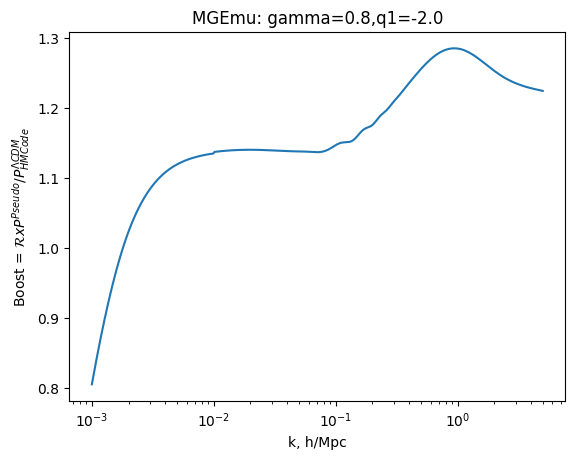

In [128]:
plt.semilogx(k_values_MGEmu, boost_MGEmu[0])
plt.title("MGEmu: gamma=0.8,q1=-2.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $\mathcal{R} x P^{Pseudo}/P^{\Lambda  CDM}_{HMCode}$")
plt.show()

## mu Sigma NL Emu Test

In [8]:
########################################################
######## Get the boosts from the emulator ##############
########################################################

emulator_nonlin_boost = cp.cosmopower_NN(restore=True,
                        restore_filename='/home/c2042999/mu-Sigma-q1-emulator/cosmosis/muSigma_emu/models/MuSigma_nonlinearboost_extAs',
                        )
emu_k_nonlin = emulator_nonlin_boost.modes
emulator_lin = cp.cosmopower_NN(restore=True,
                        restore_filename='/home/c2042999/mu-Sigma-q1-emulator/cosmosis/muSigma_emu/models/MuSigma_linear_log10ps_extAs',
                        )
emu_k_lin = emulator_lin.modes
print("Loaded nonlinear mu0-Sigma0 model")

kmin_lin = emu_k_lin[0]
kmin_nonlin = emu_k_nonlin[0]
kmax_nonlin = emu_k_nonlin[-1]

def check_params(params):
    ranges =  {
            'Omega_m': [0.2,     0.6], 
            'Omega_b': [0.03,    0.07], 
            #'H0': [58., 80.],
            'h': [0.58, 0.8],
            'ns': [0.93, 1.0],
            'As': [0.5e-09, 5.0e-09],
            'neutrino_mass': [0., 0.6],
            'mu0': [-0.9999, 2.9999],
            'sigma0': [-1., 3.],
            'q1': [-2., 2.]
                        }

    for key, (vmin, vmax) in ranges.items():
        if not (params[key][0] > vmin) and (params[key][0] < vmax):
            raise ValueError(f"emu: {key} must be in range [{vmin},{vmax}]")



Loaded nonlinear mu0-Sigma0 model


In [38]:
########################################################
########## Parameters (one step in mcmc) ###############
########################################################

params = {
    'Omega_m'     :  [0.315],
    'As'            :  [np.exp(3.07)*1.e-10],
    'Omega_b'  :  [0.05],
    'ns'            :  [0.96],
    "H0": [0.67*100.],
    "h": [0.67],
    'neutrino_mass' :  [0.000000000000000000001],
    "Omega_nu": [0.0], #[0.3/(93.14*0.67**2)]
    'w0'            :  [-1.0],
    'wa'            :  [0.0],
    "mu0": [0.0],
    "sigma0": [0.0],
    'q1'     :  [0.0],
    'z'             :  [0.]
}


kmin = 1e-4
kmax = 4
nk = 300

# check we're within the allowed bounds for the emulator
check_params(params)

In [39]:
########################################################
################# Compute the boosts ###################
########################################################

k_arr = np.logspace(np.log10(kmin), np.log10(kmax), nk)

Bk_nl = emulator_nonlin_boost.predictions_np(params)
Pk_l = emulator_lin.ten_to_predictions_np(params)

pklin_interp = [interpolate.interp1d(emu_k_lin,
                                        pk_lin_i,
                                        kind='linear',
                                        bounds_error=False,
                                        fill_value=(pk_lin_i[0], pk_lin_i[-1]),
                                        ) for pk_lin_i in Pk_l]
plin = np.array([pklin_interp[i](k_arr) for i in range(len(Bk_nl))])

bknonlin_interp = [interpolate.interp1d(emu_k_nonlin,
                                                bk_nonlin_i,
                                                kind='linear',bounds_error=False,
                                                fill_value=(bk_nonlin_i[0], bk_nonlin_i[-1]) 
                                                ) for bk_nonlin_i in Bk_nl]
boostnonlin = np.array([bknonlin_interp[i](k_arr[k_arr>=0.01]) for i in range(len(Bk_nl))])
pnonlin = plin[:, k_arr>=0.01]*boostnonlin

# concatenation of PkLin, Pk_NL
pl_left = plin[:, k_arr<emu_k_nonlin[0]]
pnl  = np.concatenate((pl_left, pnonlin),axis=1)
k_h = k_arr

/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


In [40]:
print(Bk_nl.shape)

(1, 300)


In [41]:
######################################
######## compare to ccl ##############
######################################

cosmo = ccl.Cosmology(Omega_c = params["Omega_m"][0] - params["Omega_b"][0] - params["Omega_nu"][0], 
                          Omega_b = params["Omega_b"][0],
                          h = params["h"][0],
                          n_s = params["ns"][0],
                          A_s = params["As"][0])

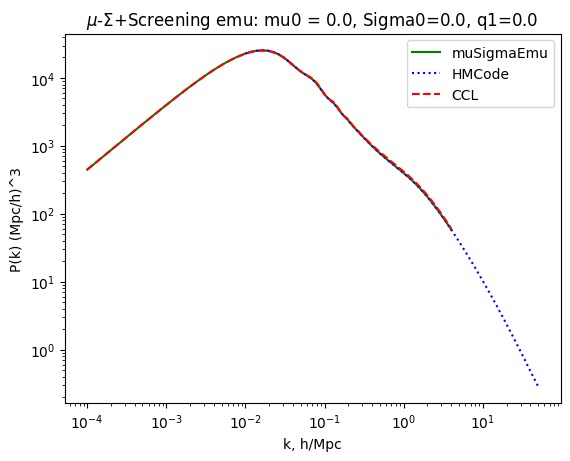

In [42]:
for i in range(len(Bk_nl)):
    plt.loglog(k_h, pnl[i], "g")
    plt.loglog(k_nonlin_HM, pk_nonlin_total_HM[i] , "b:")
    #plt.loglog(emu_k_lin, Pk_l[i])
    plt.loglog(k_h, cosmo["h"]**3*ccl.nonlin_matter_power(cosmo, k=k_h*cosmo["h"], a=1), "r--")

plt.legend(["muSigmaEmu","HMCode", "CCL"])
plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("P(k) (Mpc/h)^3")
plt.show()

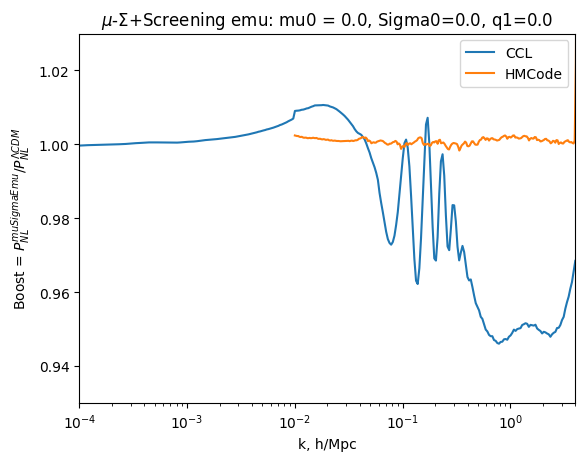

In [43]:
for i in range(len(Bk_nl)):
    plt.semilogx(k_h, pnl[i]/(cosmo["h"]**3*ccl.nonlin_matter_power(cosmo, k=k_h*cosmo["h"], a=1)))
    plt.semilogx(k_nonlin_HM, np.interp(k_nonlin_HM,k_h,pnl[i])/pk_nonlin_total_HM[0])

plt.xlim(k_h[0],k_h[-1])
plt.ylim(0.93,1.03)

plt.legend(["CCL", "HMCode"])
plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $P^{muSigmaEmu}_{NL}/P^{\Lambda  CDM}_{NL}$")
plt.show()

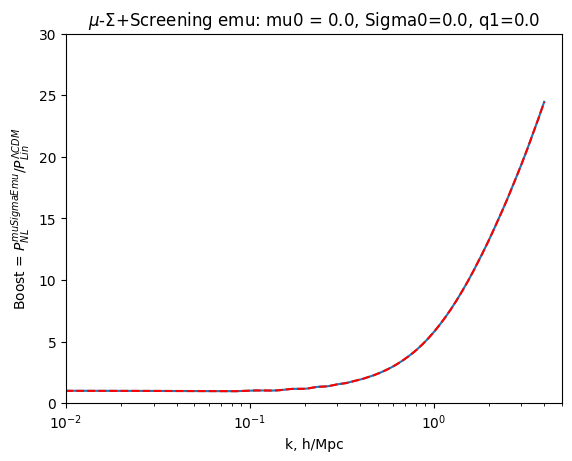

In [44]:
k_tests = k_arr[np.where(k_arr>=0.01)]
plt.semilogx(k_tests, boostnonlin[-1])
plt.semilogx(k_arr, pnl[-1]/plin[-1], "r--")
plt.xlim(1e-2,5)
plt.ylim(0,30)

plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $P^{muSigmaEmu}_{NL}/P^{\Lambda  CDM}_{Lin}$")
plt.show()

In [88]:
###############################################
############ Compare to BACCOEmu ##############
###############################################

emulator_Bacco = baccoemu.Matter_powerspectrum()

params_Bacco = {
    'omega_cold'    :  params["Omega_m"][0] - params["Omega_nu"][0],
    'A_s'   :  params["As"][0], # if A_s is not specified
    'omega_baryon'  :  params["Omega_b"][0],
    'ns'            :  params["ns"][0],
    'hubble'        :  params["h"][0],
    'neutrino_mass' :  params["neutrino_mass"][0],
    'w0'            : -1.0,
    'wa'            :  0.0,
    'expfactor'     :  1
}

k, Q_total = emulator_Bacco.get_nonlinear_boost(k=k_h, cold=False,baryonic_boost=False, **params_Bacco)
k, pk_nl_total = emulator_Bacco.get_nonlinear_pk(k=k_h, cold=False,baryonic_boost=False, **params_Bacco)
k, pk_lin_total = emulator_Bacco.get_linear_pk(k=k_h, cold=False, **params_Bacco)


Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.


/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use

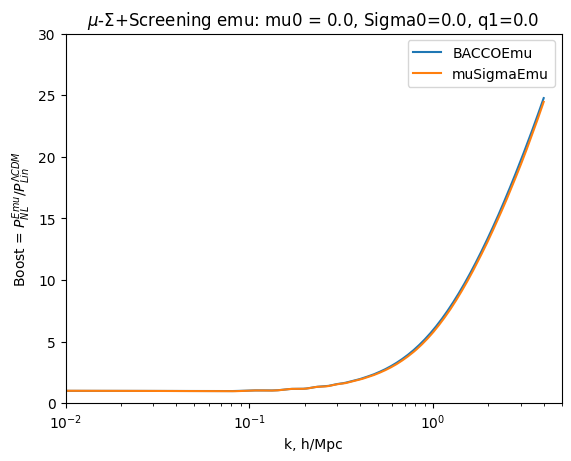

In [89]:
plt.semilogx(k, Q_total)
plt.xlim(1e-2,5)
plt.ylim(0,30)

plt.semilogx(k_tests, boostnonlin[-1])

plt.legend(["BACCOEmu", "muSigmaEmu"])
plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $P^{Emu}_{NL}/P^{\Lambda  CDM}_{Lin}$")
plt.show()


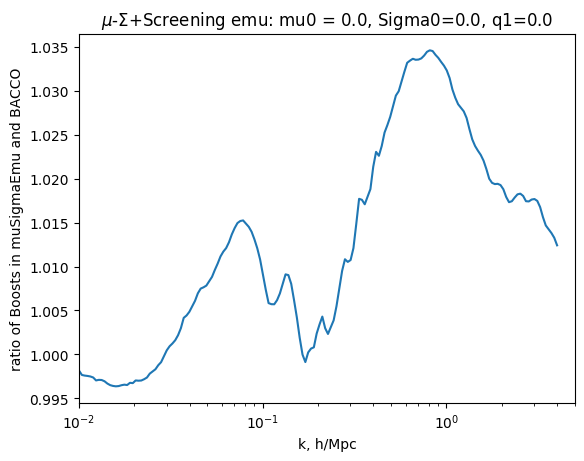

In [90]:
plt.semilogx(k, Q_total/np.interp(k,k_tests, boostnonlin[-1]))
plt.xlim(1e-2,5)
#plt.ylim(0,30)

plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("ratio of Boosts in muSigmaEmu and BACCO")
plt.show()


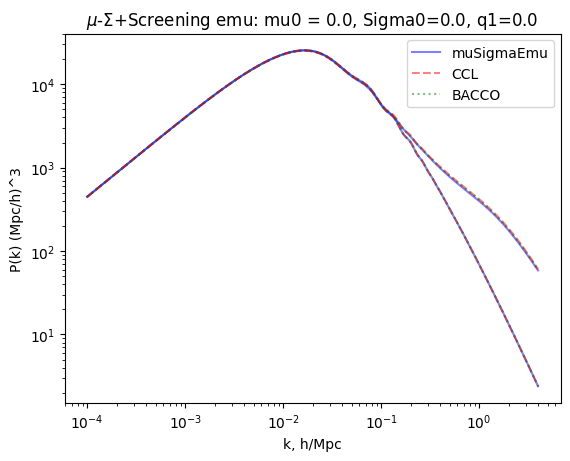

In [91]:
for i in range(len(Bk_nl)):
    plt.loglog(k_h, pnl[i], "b", alpha=0.5)
    #plt.loglog(emu_k_lin, Pk_l[i])
    plt.loglog(k_h, cosmo["h"]**3*ccl.nonlin_matter_power(cosmo, k=k_h*cosmo["h"], a=1), "r--", alpha=0.5)
    plt.loglog(k_h, pk_nl_total, "g:", alpha=0.5)

    plt.loglog(k_h, plin[i], "b", alpha=0.5)
    #plt.loglog(emu_k_lin, Pk_l[i])
    plt.loglog(k_h, cosmo["h"]**3*ccl.linear_matter_power(cosmo, k=k_h*cosmo["h"], a=1), "r--", alpha=0.5)
    plt.loglog(k_h, pk_lin_total, "g:", alpha=0.5)

plt.legend(["muSigmaEmu", "CCL", "BACCO"])
plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("P(k) (Mpc/h)^3")
plt.show()

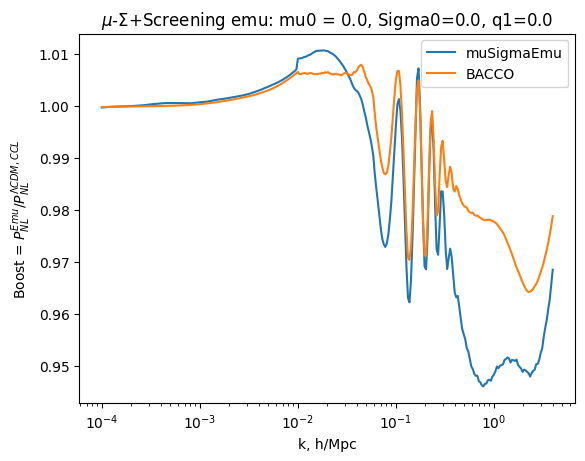

In [92]:
for i in range(len(pnl)):
    plt.semilogx(k_h, pnl[i]/(cosmo["h"]**3*ccl.nonlin_matter_power(cosmo, k=k_h*cosmo["h"], a=1)))
    plt.semilogx(k_h, pk_nl_total/(cosmo["h"]**3*ccl.nonlin_matter_power(cosmo, k=k_h*cosmo["h"], a=1)))

plt.legend(["muSigmaEmu","BACCO"])
plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Boost = $P^{Emu}_{NL}/P^{\Lambda  CDM, CCL}_{NL}$")

plt.show()

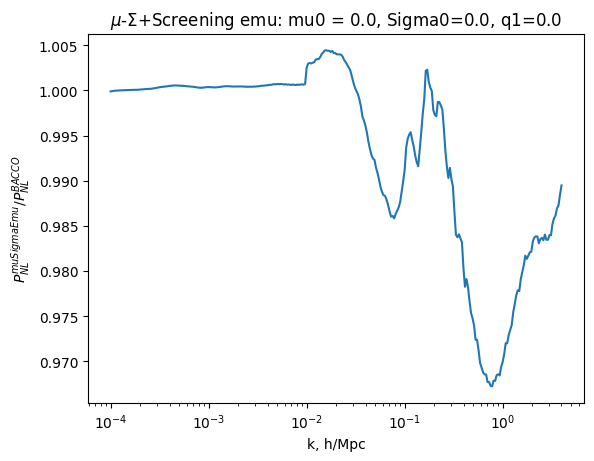

In [93]:
for i in range(len(pnl)):
    plt.semilogx(k_h, pnl[i]/pk_nl_total)

plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("$P^{muSigmaEmu}_{NL}/P^{BACCO}_{NL}$")

plt.show()

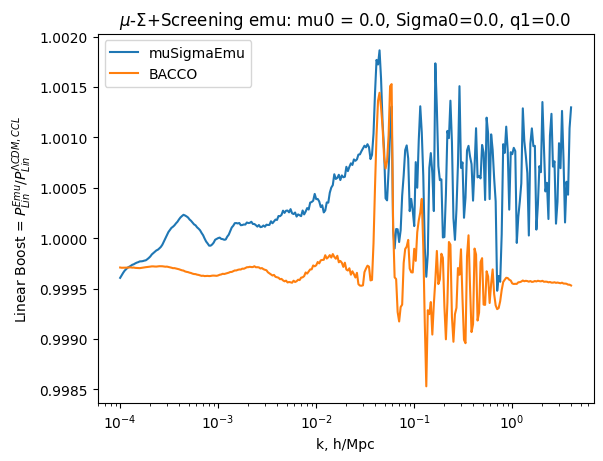

In [94]:
for i in range(len(pnl)):
    plt.semilogx(k_h, plin[i]/(cosmo["h"]**3*ccl.linear_matter_power(cosmo, k=k_h*cosmo["h"], a=1)))
    plt.semilogx(k_h, pk_lin_total/(cosmo["h"]**3*ccl.linear_matter_power(cosmo, k=k_h*cosmo["h"], a=1)))


plt.legend(["muSigmaEmu","BACCO"])
plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("Linear Boost = $P^{Emu}_{Lin}/P^{\Lambda  CDM, CCL}_{Lin}$")

plt.show()

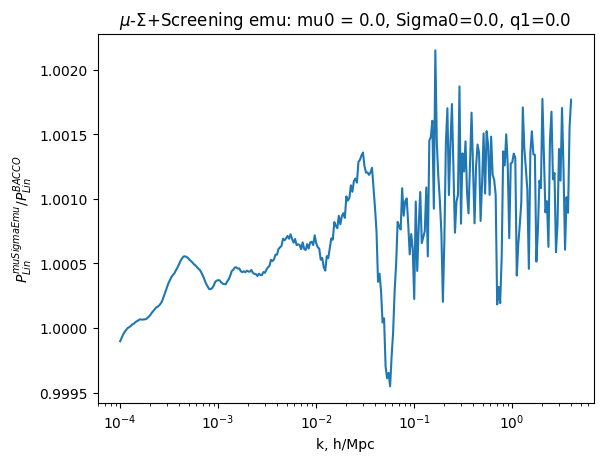

In [95]:
for i in range(len(pnl)):
    plt.semilogx(k_h, plin[i]/pk_lin_total)

plt.title(r"$\mu$-$\Sigma$+Screening emu: mu0 = 0.0, Sigma0=0.0, q1=0.0")
plt.xlabel("k, h/Mpc")
plt.ylabel("$P^{muSigmaEmu}_{Lin}/P^{BACCO}_{Lin}$")

plt.show()